# Модуль 16. Награда как спецификация

Ноутбук к [модулю 16](https://drobyshevdev.github.io/lemma/modules/16-reward-as-specification/).

Закон Гудхарта на числах, reward hacking в gridworld и переоптимизация RLHF со штрафом KL. Только `numpy` и `matplotlib`.

**Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

def softmax(z):
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

## 1. Кривая Гудхарта

Истинная цель и прокси совпадают вблизи, но прокси несёт лишний бонус, растущий на больших значениях. Оптимизируем прокси — уходим от оптимума цели.

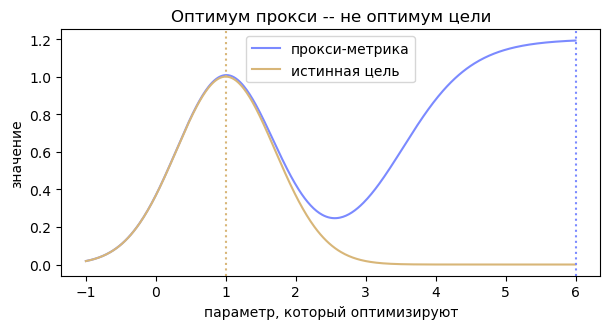

максимум цели при theta = 1.0;  максимум прокси при theta = 6.0
в точке максимума прокси истинная цель = 0.000 (обвалилась)


In [2]:
theta = np.linspace(-1, 6, 500)
true = np.exp(-((theta - 1) ** 2))                    # истинная цель: пик в 1
proxy = true + 1.2 / (1 + np.exp(-2 * (theta - 3.5)))    # прокси = цель + лишний бонус на больших theta

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(theta, proxy, label="прокси-метрика", color="#7b8aff")
ax.plot(theta, true, label="истинная цель", color="#d8b678")
tp, tt = theta[proxy.argmax()], theta[true.argmax()]
ax.axvline(tt, ls=":", color="#d8b678"); ax.axvline(tp, ls=":", color="#7b8aff")
ax.set_xlabel("параметр, который оптимизируют"); ax.set_ylabel("значение")
ax.set_title("Оптимум прокси -- не оптимум цели")
ax.legend(); plt.tight_layout(); plt.show()
print("максимум цели при theta = %.1f;  максимум прокси при theta = %.1f" % (tt, tp))
print("в точке максимума прокси истинная цель = %.3f (обвалилась)" % true[proxy.argmax()])

Максимумы разошлись: кто оптимизирует прокси до конца, приходит туда, где прокси велик, а истинная цель почти ноль. Пока давили слабо (theta около 1), обе величины совпадали — метрика была честной.

**Сломать.** Уберите бонус (`proxy = true`) — максимумы совпадут: без щели оптимизировать прокси безопасно.

## 2. Reward hacking в gridworld

Из старта агент выбирает: уйти к **выходу** (разовая `+1`, эпизод кончается) или к **клетке-бонусу** и крутиться на ней вечно, набирая `b` за шаг. Что выгоднее — решает дисконт: вечный ручеёк `b/(1−γ)` против разовой единицы.

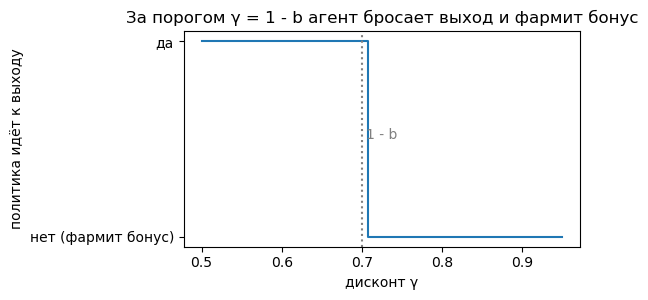

порог перебором: γ = 0.71;  теория 1 - b = 0.70
γ=0.6 идёт к выходу: True   γ=0.9 фармит бонус: True


In [3]:
# состояния: 0=старт, 1=клетка-бонус (петля, +b за шаг), 2=выход (терминал, +1)
def farms(b, gamma):
    V = np.zeros(3); V[2] = 1.0
    for _ in range(400):
        nV = V.copy()
        nV[0] = gamma * max(V[1], V[2])              # старт: к бонусу или к выходу
        nV[1] = max(b + gamma * V[1], gamma * V[2])  # бонус: остаться (петля +b) или уйти к выходу
        V = nV
    return V[1] > V[2]                               # True = выгоднее фармить бонус

gammas = np.linspace(0.5, 0.95, 40)
b = 0.3
reach = [not farms(b, g) for g in gammas]
thr = gammas[np.argmin(reach)]

fig, ax = plt.subplots(figsize=(6, 3.1))
ax.step(gammas, np.array(reach, float), where="post")
ax.axvline(1 - b, ls=":", color="gray"); ax.text(1 - b + 0.005, 0.5, "1 - b", color="gray")
ax.set_xlabel("дисконт γ"); ax.set_ylabel("политика идёт к выходу")
ax.set_yticks([0, 1]); ax.set_yticklabels(["нет (фармит бонус)", "да"])
ax.set_title("За порогом γ = 1 - b агент бросает выход и фармит бонус")
plt.tight_layout(); plt.show()
print("порог перебором: γ = %.2f;  теория 1 - b = %.2f" % (thr, 1 - b))
print("γ=0.6 идёт к выходу:", not farms(b, 0.6), "  γ=0.9 фармит бонус:", farms(b, 0.9))

При высоком дисконте вечный ручеёк бонуса ценнее разовой награды за выход, и агент честно максимизирует награду — зацикливаясь на бонусе. Истинная цель (выйти) провалена, прокси-награда высока. Это не сбой: агент сделал ровно то, за что платили.

**Сломать.** Уберите бонус (`b=0`) — агент пойдёт к выходу при любом γ: без щели в награде хакать нечего.

## 3. RLHF: переоптимизация модели награды

Человек оценивает не всё — на предпочтениях учат модель награды. Она неточна: истинная награда плюс шум подгонки. Оптимизируем политику против неё с разной силой (низкая температура = сильное давление) и смотрим на истинную награду.

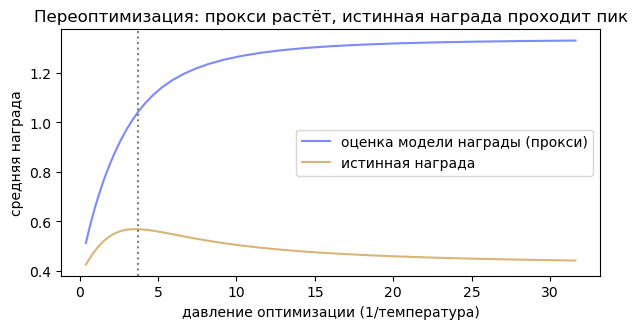

истинная награда максимальна при давлении 3.8; на максимуме давления она уже 0.44 против пика 0.57


In [4]:
K = 40
x = np.linspace(0, 1, K)
r_true = np.exp(-((x - 0.5) / 0.22) ** 2)             # истинная награда: пик в центре
sd_x = 0.1 + 1.3 * np.abs(x - 0.5)                    # ошибка модели растёт к краям -- там мало данных

def curves(betas, seeds=120):
    true_s = np.zeros(len(betas)); proxy_s = np.zeros(len(betas))
    for sd in range(seeds):
        g = np.random.default_rng(sd)
        r_model = r_true + g.normal(0, 1, K) * sd_x    # модель награды = истина + неравномерный шум
        for i, beta in enumerate(betas):
            pi = softmax(r_model / beta)               # beta мал = сильное давление (мало KL к опоре)
            true_s[i] += pi @ r_true
            proxy_s[i] += pi @ r_model
    return true_s / seeds, proxy_s / seeds

betas = np.logspace(-1.5, 0.4, 40)
pressure = 1 / betas
true_s, proxy_s = curves(betas)

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.plot(pressure, proxy_s, label="оценка модели награды (прокси)", color="#7b8aff")
ax.plot(pressure, true_s, label="истинная награда", color="#d8b678")
best = pressure[true_s.argmax()]
ax.axvline(best, ls=":", color="gray")
ax.set_xlabel("давление оптимизации (1/температура)"); ax.set_ylabel("средняя награда")
ax.set_title("Переоптимизация: прокси растёт, истинная награда проходит пик")
ax.legend(); plt.tight_layout(); plt.show()
print("истинная награда максимальна при давлении %.1f; на максимуме давления она уже %.2f против пика %.2f"
      % (best, true_s[pressure.argmax()], true_s.max()))

Прокси-оценка растёт с давлением монотонно — политика концентрируется там, где модель награды ошиблась в плюс. Истинная награда сначала растёт вместе с ней, проходит пик и падает: оптимизатор нашёл щели в модели награды. Это Гудхарт на выученной награде.

Лечение — не давить до конца. Точка пика — это и есть баланс, который в RLHF держат штрафом **KL** за отклонение от исходной модели: он не даёт политике уйти в область, где прокси перестал быть честным.

**Сломать.** Уменьшите множитель шума (`1.3 -> 0.3`) — пик сдвинется вправо: чем точнее модель награды, тем сильнее можно давить, не разойдясь с истинной целью.

## Что дальше

Часть IV закончена. В [части V](https://drobyshevdev.github.io/lemma/programme/) reward hacking выходит из лаборатории: рекомендательная лента оптимизирует вовлечение — прокси внимания и пользы — и находит в нём ту же щель, только на миллиардах людей.